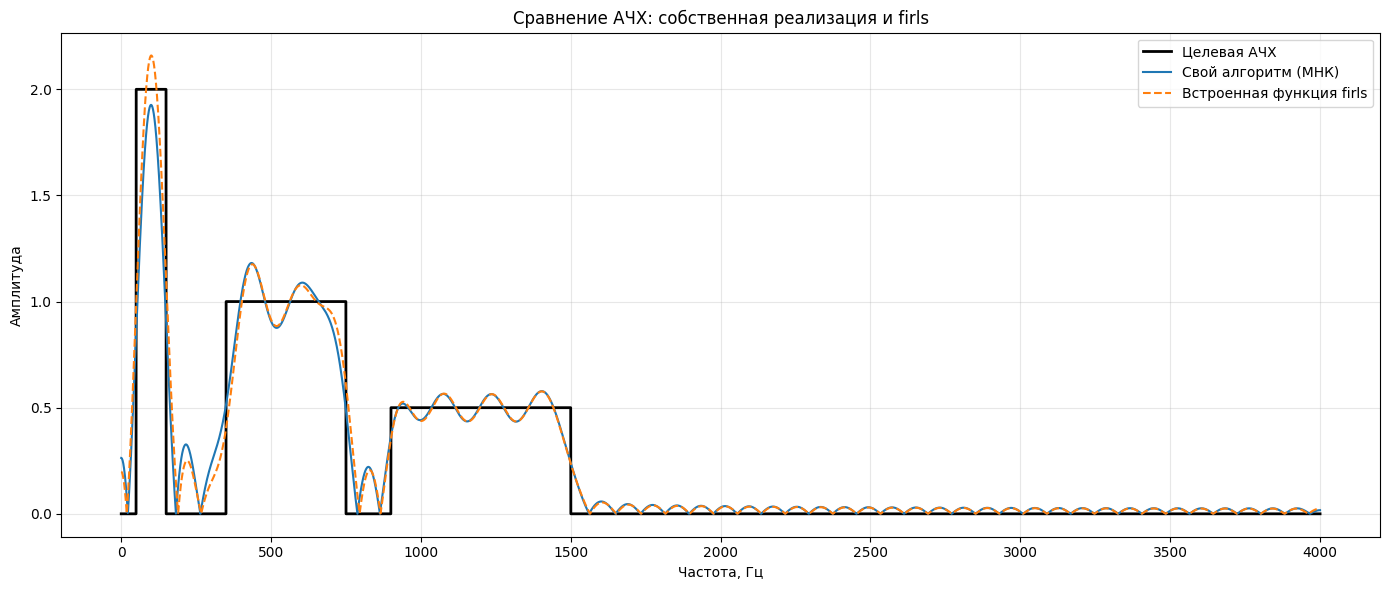

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firls, freqz

fs = 8000 # Частота дискретизации, Гц
L = 2 # Множитель для плотности сетки частот при расчете АЧХ
N = 101 # Длина импульсной характеристики (нечетная для КИХ Типа I)

def H_d(f):
    """
    Задание идеальной амплитудно-частотной характеристики (АЧХ).
    """
    f = np.array(f)
    result = np.zeros_like(f, dtype=float)
    result = np.where((f >= 50) & (f <= 150), 2.0, result)
    result = np.where((f >= 350) & (f <= 750), 1.0, result)
    result = np.where((f >= 900) & (f <= 1500), 0.5, result)
    return result

# Центр симметрии импульсной характеристики (групповая задержка)
M = (N - 1) // 2
# Дискретная сетка частот для решения задачи МНК
omega = np.linspace(0, np.pi, N)
frequencies = omega * fs / (2 * np.pi)

# Вектор целевых значений АЧХ на узлах сетки
A_resp = H_d(frequencies)

# Формирование матрицы базисных функций
H_matrix = np.zeros((N, M + 1))
H_matrix[:, 0] = 1.0
for k in range(1, M + 1):
    H_matrix[:, k] = 2 * np.cos(k * omega)

# Приведение целевого вектора к виду столбца для матричных операций
y_vec = A_resp.reshape(-1, 1)

# Решение переопределенной СЛАУ методом наименьших квадратов через нормальные уравнения
# x = (H^T * H)^-1 * H^T * y
x_solution = np.linalg.inv(H_matrix.T @ H_matrix) @ H_matrix.T @ y_vec
x_solution = x_solution.flatten()

# Восстановление полной симметричной импульсной характеристики h[n]
h = np.zeros(N)
h[M] = x_solution[0]
for k in range(1, M + 1):
    h[M - k] = x_solution[k]
    h[M + k] = x_solution[k]

f_plot = np.linspace(0, fs / 2, L * fs // 2)

# Расчет комплексной частотной характеристики
w_impl, resp_impl = freqz(h, 1, f_plot, fs=fs)

# границы частотных полос
bands = [0, 50, 50, 150, 150, 350, 350, 750, 750, 900, 900, 1500, 1500, fs // 2]
# целевые значения АЧХ на границах соответствующих полос
desired = [0, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0.5, 0.5, 0, 0]
bandpass_lib = firls(N, bands, desired, fs=fs)
w_lib, resp_lib = freqz(bandpass_lib, 1, f_plot, fs=fs)


plt.figure(figsize=(14, 6))
plt.plot(f_plot, H_d(f_plot), label="Целевая АЧХ", color="black", linewidth=2)
plt.plot(w_impl, np.abs(resp_impl), label="Свой алгоритм (МНК)", linewidth=1.5)
plt.plot(w_lib, np.abs(resp_lib), label="Встроенная функция firls", linewidth=1.5, linestyle="--")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.title("Сравнение АЧХ: собственная реализация и firls")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

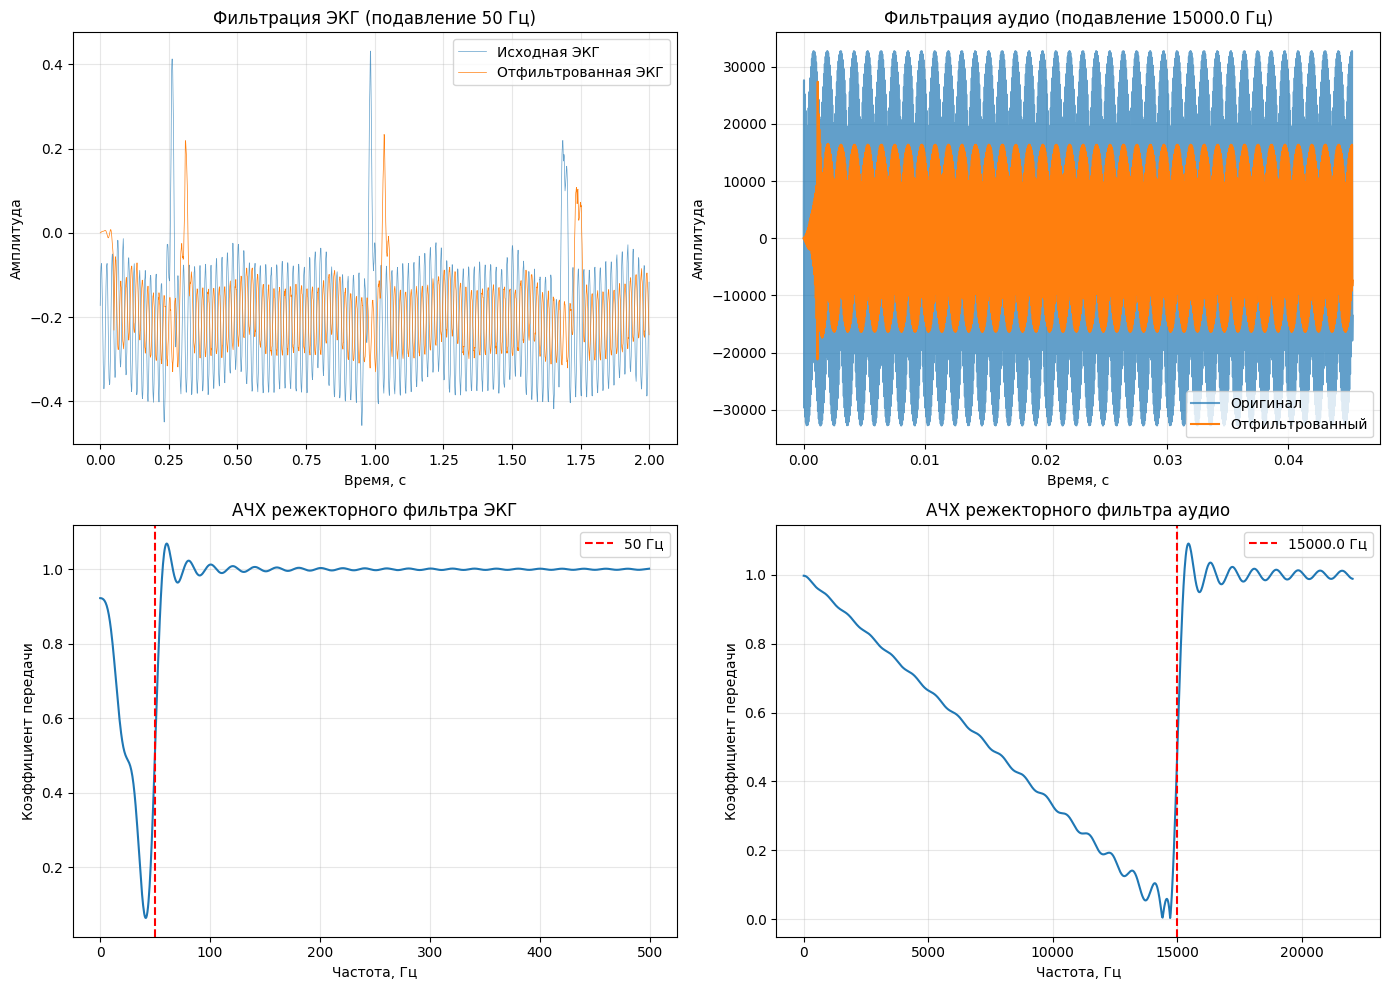

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firls, freqz, lfilter
from scipy.io import wavfile

fs_audio, x_audio = wavfile.read('tune.wav')
x_audio = x_audio.astype(np.float64)


# Вычисление спектра сигнала для поиска доминирующей частоты шума
X_audio = np.fft.rfft(x_audio)
freqs_audio = np.fft.rfftfreq(len(x_audio), 1 / fs_audio)
# Исключаем нулевой индекс (постоянную составляющую) из поиска максимума
idx_noise = np.argmax(np.abs(X_audio)[1:]) + 1
f_noise = freqs_audio[idx_noise]

# Проектирование режекторного КИХ-фильтра для подавления выявленной помехи
# Полоса подавления ограничена частотами [f_noise - 20, f_noise + 20] Гц
bw_audio = 20
h_audio = firls(101, [0, f_noise - bw_audio, f_noise + bw_audio, fs_audio / 2], [1, 0, 1, 1], fs=fs_audio)
# Применение спроектированного фильтра к исходному сигналу
y_audio = lfilter(h_audio, 1, x_audio)

ecg_data = np.loadtxt('ecg.dat')
t_ecg = ecg_data[:, 0]
x_ecg = ecg_data[:, 1]
fs_ecg = int(round(1 / (t_ecg[1] - t_ecg[0])))

# Проектирование режекторного фильтра для удаления сетевой наводки 50 Гц
# Полоса подавления ограничена частотами [48, 52] Гц
f_50 = 50
bw_ecg = 2
h_ecg = firls(101, [0, f_50 - bw_ecg, f_50 + bw_ecg, fs_ecg / 2], [1, 0, 1, 1], fs=fs_ecg)
# Фильтрация зашумленного сигнала ЭКГ
y_ecg = lfilter(h_ecg, 1, x_ecg)

# Расчет частотных характеристик для построения АЧХ
w_ecg, resp_ecg = freqz(h_ecg, worN=1024, fs=fs_ecg)
w_audio, resp_audio = freqz(h_audio, worN=1024, fs=fs_audio)

plt.figure(figsize=(14, 10))

# Исходные сигналы
plt.subplot(2, 2, 1)
plot_len_ecg = min(len(x_ecg), 2000)
plt.plot(t_ecg[:plot_len_ecg], x_ecg[:plot_len_ecg], label='Исходная ЭКГ', alpha=0.7, linewidth=0.5)
plt.plot(t_ecg[:plot_len_ecg], y_ecg[:plot_len_ecg], label='Отфильтрованная ЭКГ', linewidth=0.5)
plt.title('Фильтрация ЭКГ (подавление 50 Гц)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
t_audio = np.arange(len(x_audio)) / fs_audio
plot_len_audio = min(len(x_audio), 2000)
plt.plot(t_audio[:plot_len_audio], x_audio[:plot_len_audio], label='Оригинал', alpha=0.7)
plt.plot(t_audio[:plot_len_audio], y_audio[:plot_len_audio], label='Отфильтрованный')
plt.title(f'Фильтрация аудио (подавление {f_noise:.1f} Гц)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)

# АЧХ фильтров
plt.subplot(2, 2, 3)
plt.plot(w_ecg, np.abs(resp_ecg), linewidth=1.5)
plt.title('АЧХ режекторного фильтра ЭКГ')
plt.xlabel('Частота, Гц')
plt.ylabel('Коэффициент передачи')
plt.axvline(f_50, color='r', linestyle='--', label=f'{f_50} Гц')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(w_audio, np.abs(resp_audio), linewidth=1.5)
plt.title(f'АЧХ режекторного фильтра аудио')
plt.xlabel('Частота, Гц')
plt.ylabel('Коэффициент передачи')
plt.axvline(f_noise, color='r', linestyle='--', label=f'{f_noise:.1f} Гц')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

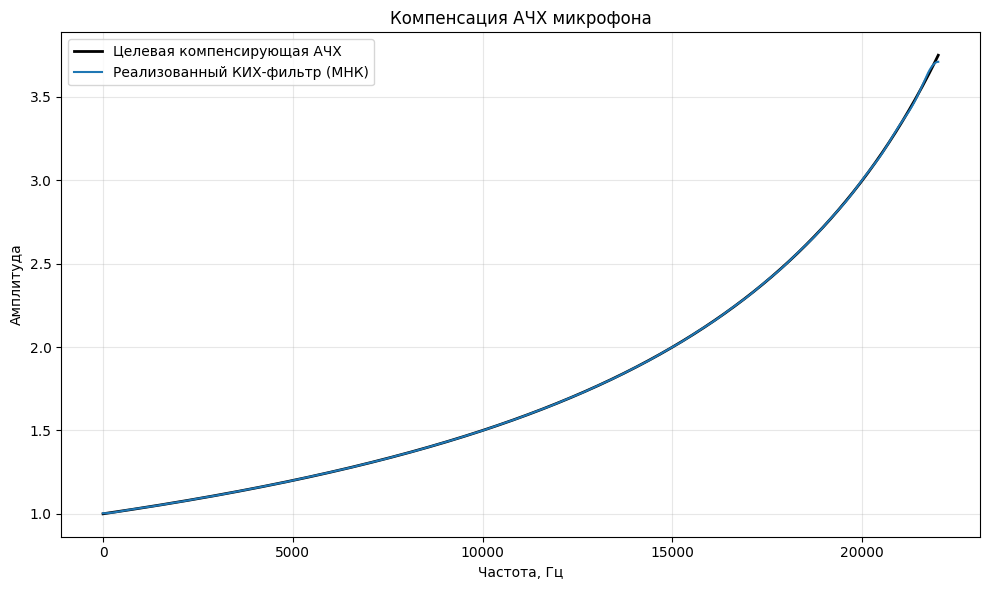

In [ ]:
Fc = 30000 # Критическая частота микрофона, Гц
fs_task3 = 44000 # Частота дискретизации АЦП, Гц
N_task3 = 101 # Длина импульсной характеристики КИХ-фильтра
M_task3 = (N_task3 - 1) // 2 # Центр симметрии (групповая задержка)


# Расчет целевой АЧХ компенсирующего фильтра
# Микрофон имеет АЧХ Ha(F) = 1 - |F|/Fc, поэтому компенсирующий фильтр 
# должен иметь АЧХ H_comp(F) = 1 / Ha(F) для выравнивания общего спектра
freq_grid_3 = np.linspace(0, fs_task3 / 2, 1000)
H_target_3 = 1.0 / (1.0 - np.abs(freq_grid_3) / Fc)

# Переход к нормированным цифровым частотам для формирования базисных функций
omega_grid_3 = 2 * np.pi * freq_grid_3 / fs_task3
target_amp_3 = H_target_3.reshape(-1, 1)

# Формирование матрицы системы для метода наименьших квадратов (МНК)
# Для КИХ-фильтра Типа I (нечетная длина, симметричная ИХ) амплитудная 
# характеристика раскладывается в ряд по косинусам: A(w) = h[M] + sum(2*h[M-k]*cos(k*w))
H_matrix_3 = np.zeros((len(freq_grid_3), M_task3 + 1))
H_matrix_3[:, 0] = 1.0
for k in range(1, M_task3 + 1):
    H_matrix_3[:, k] = 2 * np.cos(k * omega_grid_3)

# Решение переопределенной СЛАУ методом наименьших квадратов
# Ищем коэффициенты, минимизирующие квадрат ошибки аппроксимации целевой АЧХ
x_solution_3 = np.linalg.lstsq(H_matrix_3, target_amp_3, rcond=None)[0].flatten()

# Восстановление полной симметричной импульсной характеристики фильтра h[n]
h_comp = np.zeros(N_task3)
h_comp[M_task3] = x_solution_3[0]
for k in range(1, M_task3 + 1):
    h_comp[M_task3 - k] = x_solution_3[k]
    h_comp[M_task3 + k] = x_solution_3[k]

# Вычисление комплексной частотной характеристики реализованного фильтра
w_comp, resp_comp = freqz(h_comp, 1, freq_grid_3, fs=fs_task3)

plt.figure(figsize=(10, 6))
plt.plot(freq_grid_3, H_target_3, label="Целевая компенсирующая АЧХ", color="black", linewidth=2)
plt.plot(w_comp, np.abs(resp_comp), label="Реализованный КИХ-фильтр (МНК)", linewidth=1.5)
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.title("Компенсация АЧХ микрофона")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()